In [25]:
import glob

import pandas as pd
import numpy as np
from collections import defaultdict

In [26]:
atn_files = glob.glob('4concept_attentions/*/*concept_attention_weights.npy')

In [27]:
atns = []
for p in atn_files:
    fold_atn = np.load(p)
    atns.append(fold_atn)
attentions = np.vstack(atns)
    

In [28]:
attentions.shape

(7935, 4)

In [41]:
import numpy as np
import os
from collections import defaultdict

# atn_files = [...]  # your list of .npy file paths

# Step 1: group by repeat folder
data = defaultdict(list)

for path in atn_files:
    # extract repeat (parent folder name)
    repeat = os.path.basename(os.path.dirname(path))  # e.g. "1"
    data[repeat].append(path)

# Step 2: sort within each repeat by fold number
for repeat in data:
    data[repeat] = sorted(
        data[repeat],
        key=lambda x: int(os.path.basename(x).split("_")[0])  # "7_numpy.npy" → 7
    )

# Step 3: load arrays (so each entry is now list of (n,4) arrays)
for repeat in data:
    data[repeat] = [np.load(f) for f in data[repeat]]

# Step 4: average across repeats for each fold index
num_folds = len(data[next(iter(data))])  # assume all repeats have same # of folds
fold_means = []

for fold_idx in range(num_folds):
    # collect all repeats for this fold index
    fold_stack = np.stack([data[r][fold_idx] for r in data], axis=0)  # (num_repeats, n, 4)
    fold_mean = fold_stack.mean(axis=0)  # average over repeats → (n, 4)
    fold_means.append(fold_mean)

# Step 5: average across folds → final (n, 4)
final_mean = np.stack(fold_means, axis=1)

print(final_mean.shape)  # (n, 4)


ValueError: all input arrays must have the same shape

In [50]:
attentions = np.vstack(fold_means)

/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_28383/3950593782.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = cm.get_cmap('magma', 256)


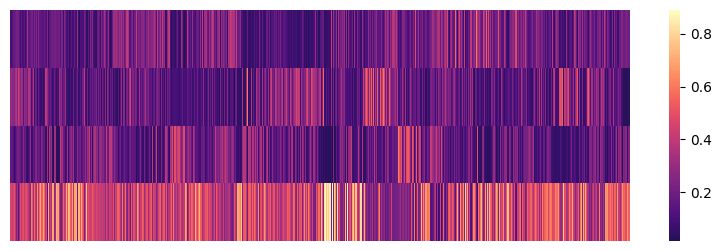

In [51]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

from matplotlib.colors import ListedColormap

# Base magma colormap
base = cm.get_cmap('magma', 256)

# Mix with white (control blend factor)
soft_magma = ListedColormap(base(np.linspace(0.15, 1, 256)))  # trims dark bottom 15%
#soft_magma = ListedColormap(cm.get_cmap('magma')(np.linspace(0, 0.9, 256)))
#base = cm.get_cmap('magma', 256)

# Create a softened version (skip darkest 20%)
#soft_magma = ListedColormap(base(np.linspace(0.2, 1, 256)))

plt.figure(figsize=(10,3))

# Plot heatmap
sns.heatmap(attentions.T, cmap=soft_magma,cbar=True, xticklabels=False, yticklabels=False,  annot=False)
plt.yticks()

plt.show()


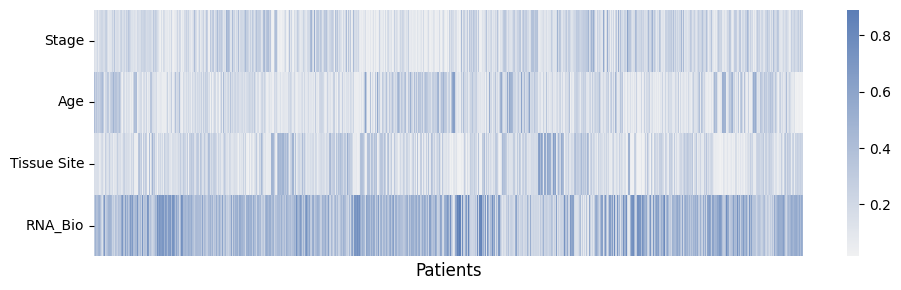

In [54]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))

# Diverging palette (good if you want a midpoint emphasis, e.g. 0.5)
cmap = sns.diverging_palette(220, 20, s=90, l=50, as_cmap=True)#
cmap = sns.diverging_palette(220, 20, s=90, l=50, as_cmap=True)
pal = sns.light_palette("#4c72b0", n_colors=256, as_cmap=True)

# Heatmap (transpose so concepts are rows, samples are columns)
sns.heatmap(
    attentions.T,
    cmap=pal,          # or pal if you want sequential blues
    center=0.5,         # makes diverging palette centered at 0.5
    cbar=True,
    xticklabels=False,
    yticklabels=["Stage", "Age", "Tissue Site", "RNA_Bio"],
    annot=False
)

plt.xlabel("Patients", fontsize=12)
plt.ylabel("", fontsize=12)

plt.tight_layout()
#plt.savefig('weights_heatmap.png')
plt.show()


/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_28383/2662001776.py:12: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(
/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_28383/2662001776.py:18: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(


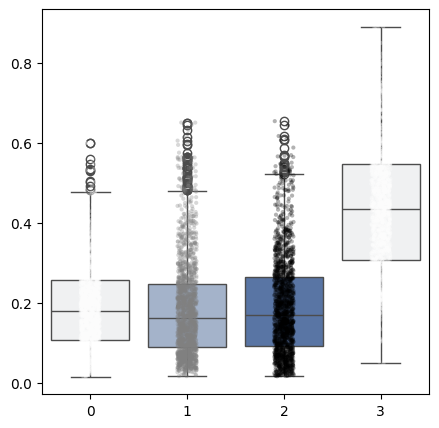

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
# Your palette for boxes (shades of blue)
pal = sns.light_palette("#4c72b0", n_colors=3)

# Custom dot colors: map to white, grey, black
dot_colors = ["white", "grey", "black"]

# Boxplot
sns.boxplot(
    data=attentions,
    palette=pal
)

# Stripplot with matching group dot colors
sns.stripplot(
    data=attentions,
    palette=dot_colors,   # <-- custom mapping
    alpha=0.3,
    size=3,
    jitter=True
)

plt.savefig('box_weights_heatmap.png')
plt.show()


In [63]:
import pandas as pd

df = pd.DataFrame(attentions, columns=["Stage", "Age", "Tissue Site"])


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pal = sns.light_palette("#4c72b0", n_colors=3)
dot_colors = ["white", "grey", "black"]

sns.boxplot(data=df, palette=pal)
sns.stripplot(data=df, palette=dot_colors, alpha=0.6, size=3, jitter=True, dodge=False)

plt.ylabel("Attention Weight", fontsize=12)
plt.xlabel("")   # remove the default "variable" label
plt.title("Attention Weights by Group", fontsize=14, weight="bold")
plt.show()


In [61]:
!pip install statannotations

/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_9170/1550487459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="Group", y="Attention Weight", data=df_melt, palette=pal)
/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_9170/1550487459.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Group", y="Attention Weight", data=df_melt, palette=dot_colors, alpha=0.6, size=3, jitter=True)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Stage vs. Age: Wilcoxon test (paired samples), P_val:3.501e-04 Stat=5.648e+05
Age vs. Tissue Site: Wilcoxon test (paired samples), P_val:7.642e-227 Stat=4.293e+04
Stage vs. Tissue Site: Wilcoxon test (paired samples), P_val:1.374e-223 Stat=4.719e+04


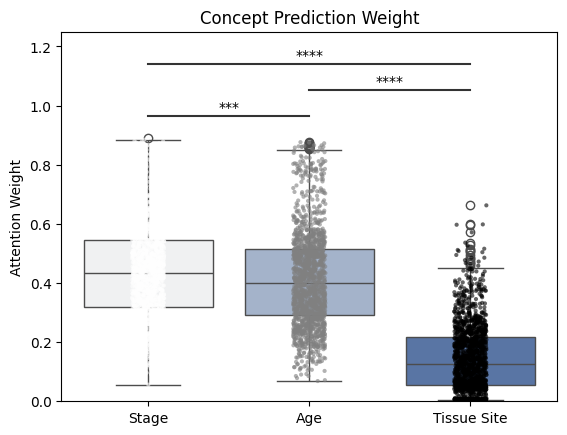

In [82]:
from statannotations.Annotator import Annotator

# Melt the df into long form (Seaborn expects this for Annotator)
df_melt = df.melt(var_name="Group", value_name="Attention Weight")

ax = sns.boxplot(x="Group", y="Attention Weight", data=df_melt, palette=pal)
sns.stripplot(x="Group", y="Attention Weight", data=df_melt, palette=dot_colors, alpha=0.6, size=3, jitter=True)
plt.ylim(0, 1.05)   # extend y-axis slightly (assuming your data is in [0,1])

# Define the pairs you want to compare
pairs = [("Stage", "Age"), ("Stage", "Tissue Site"), ("Age", "Tissue Site")]
pairs = [("Stage", "Age"), ("Stage", "Tissue Site"), ("Age", "Tissue Site")]

# Add statistical annotations
annotator = Annotator(ax, pairs, data=df_melt, x="Group", y="Attention Weight")
annotator.configure(
    test="Wilcoxon",
    text_format="star",
    line_offset_to_group=0.005,  # vertical spacing from boxes
    line_height=0.0001            # spacing between multiple comparisons
)

annotator.apply_and_annotate()


plt.ylim(0, 1.25)  # add more headroom
plt.ylabel("Attention Weight")
plt.xlabel("")
plt.title("Concept Prediction Weight")
plt.savefig('concept_weights_boxplot.png')
plt.show()
